# Airline Passenger Data Analysis Using Python
# Final Project
Developed by:Rakshita and Priya

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [2]:
df = pd.read_csv('airline_passenger_analysis_sample.csv')
df.head()

,Passenger_ID,Passenger_Name,Gender,Age,Country,Flight_Number,Airline,Source,Destination,Travel_Date,Departure_Time,Arrival_Time,Travel_Class,Ticket_Price,Payment_Method,Booking_Channel,Baggage_Weight,Flight_Distance,Flight_Duration,Rating
0,P1001,Passenger_1,Female,31,India,QP129,Akasa Air,Mumbai,Delhi,2025-03-07,03:45,06:40,Business,10237,UPI,Travel Agent,24,1390,175,4.4
1,P1002,Passenger_2,Male,42,UAE,QP843,Air India,Hyderabad,Delhi,2025-03-23,00:00,01:06,First,13142,Card,Mobile App,25,1254,66,3.7
2,P1003,Passenger_3,Male,29,Singapore,AI860,Vistara,Hyderabad,Goa,2025-03-16,00:45,04:07,First,17609,Net Banking,Travel Agent,16,1542,202,3.6
3,P1004,Passenger_4,Female,44,UAE,UK661,Vistara,Goa,Pune,2025-05-31,01:45,03:47,Economy,14685,Net Banking,Travel Agent,26,742,122,4.6
4,P1005,Passenger_5,Female,63,Nepal,6E272,SpiceJet,Jaipur,Pune,2025-04-05,15:00,18:00,Economy,3212,UPI,Website,27,1250,180,3.8


# Data Exploration

In [6]:
print(df.shape)
print()
print(df.info)
print()
df.describe()
print()


(100, 20)

<bound method DataFrame.info of    Passenger_ID Passenger_Name  Gender  Age    Country Flight_Number  \
0         P1001    Passenger_1  Female   31      India         QP129   
1         P1002    Passenger_2    Male   42        UAE         QP843   
2         P1003    Passenger_3    Male   29  Singapore         AI860   
3         P1004    Passenger_4  Female   44        UAE         UK661   
4         P1005    Passenger_5  Female   63      Nepal         6E272   
..          ...            ...     ...  ...        ...           ...   
95        P1096   Passenger_96  Female   65      India         AI423   
96        P1097   Passenger_97    Male   64  Singapore         QP301   
97        P1098   Passenger_98    Male   18        UAE         AI636   
98        P1099   Passenger_99    Male   30  Singapore         SG536   
99        P1100  Passenger_100  Female   56      Nepal         SG796   

      Airline     Source Destination Travel_Date Departure_Time Arrival_Time  \
0   Akasa Ai

# Data Cleaning

In [10]:
print(df.isnull().sum())
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)
df['Travel_Date']=pd.to_datetime(df['Travel_Date'])


Passenger_ID       0
Passenger_Name     0
Gender             0
Age                0
Country            0
Flight_Number      0
Airline            0
Source             0
Destination        0
Travel_Date        0
Departure_Time     0
Arrival_Time       0
Travel_Class       0
Ticket_Price       0
Payment_Method     0
Booking_Channel    0
Baggage_Weight     0
Flight_Distance    0
Flight_Duration    0
Rating             0
dtype: int64
0


# Feature Engineering

In [11]:
df['Month']=df['Travel_Date'].dt.month_name()
df['Day']=df['Travel_Date'].dt.day_name()
bins=[17,25,35,45,60,100]
labels=['18-25','26-35','36-45','46-60','60+']
df['Age_Group']=pd.cut(df['Age'],bins=bins,labels=labels)
df.head()

,Passenger_ID,Passenger_Name,Gender,Age,Country,Flight_Number,Airline,Source,Destination,Travel_Date,...,Ticket_Price,Payment_Method,Booking_Channel,Baggage_Weight,Flight_Distance,Flight_Duration,Rating,Month,Day,Age_Group
0,P1001,Passenger_1,Female,31,India,QP129,Akasa Air,Mumbai,Delhi,2025-03-07,...,10237,UPI,Travel Agent,24,1390,175,4.4,March,Friday,26-35
1,P1002,Passenger_2,Male,42,UAE,QP843,Air India,Hyderabad,Delhi,2025-03-23,...,13142,Card,Mobile App,25,1254,66,3.7,March,Sunday,36-45
2,P1003,Passenger_3,Male,29,Singapore,AI860,Vistara,Hyderabad,Goa,2025-03-16,...,17609,Net Banking,Travel Agent,16,1542,202,3.6,March,Sunday,26-35
3,P1004,Passenger_4,Female,44,UAE,UK661,Vistara,Goa,Pune,2025-05-31,...,14685,Net Banking,Travel Agent,26,742,122,4.6,May,Saturday,36-45
4,P1005,Passenger_5,Female,63,Nepal,6E272,SpiceJet,Jaipur,Pune,2025-04-05,...,3212,UPI,Website,27,1250,180,3.8,April,Saturday,60+


## Business Question
### Total passengers

In [12]:
len(df)


100

### Total Revenue

In [13]:
df['Ticket_Price'].sum()

1062928

### Average Ticket Price

df['Ticket_Price'].mean()

### Passengers by airline

In [15]:
df['Airline'].value_counts()

Airline
Akasa Air    23
IndiGo       20
Air India    19
Vistara      19
SpiceJet     19
Name: count, dtype: int64

### Revenue by airline

In [16]:
df.groupby('Airline')['Ticket_Price'].sum()

Airline
Air India    200294
Akasa Air    251866
IndiGo       190958
SpiceJet     207629
Vistara      212181
Name: Ticket_Price, dtype: int64

# Visualization
## Airline-wise passengers

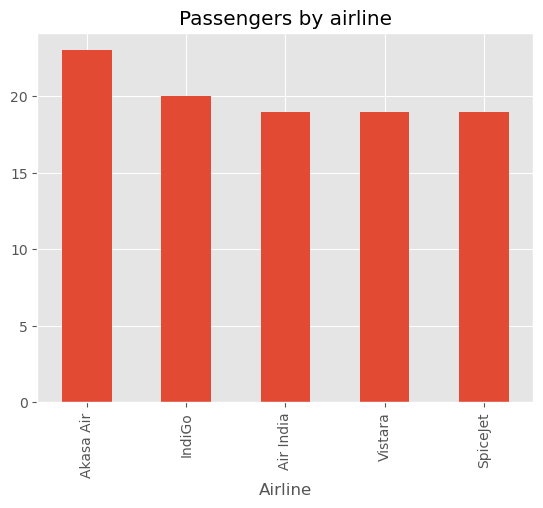

In [17]:
df['Airline'].value_counts().plot(kind='bar')
plt.title('Passengers by airline')
plt.show()

## Travel Class Distribution

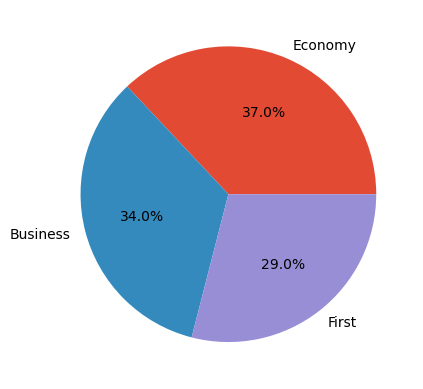

In [21]:
df['Travel_Class'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.ylabel('')
plt.show()

## Monthly Bookings

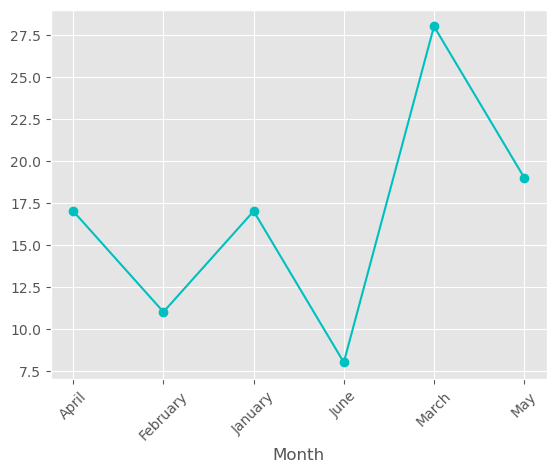

In [23]:
df.groupby('Month').size().plot(kind='line',marker='o',color="c")
plt.xticks(rotation=45)
plt.show()

## Ticket price distribution

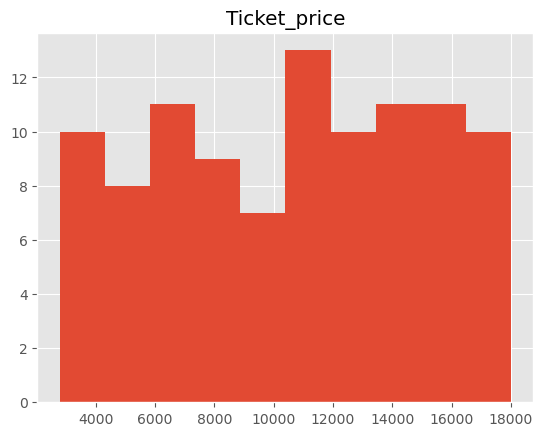

In [25]:
plt.hist(df['Ticket_Price'],bins=10)
plt.title('Ticket_price')
plt.show()

## Price vs Distance

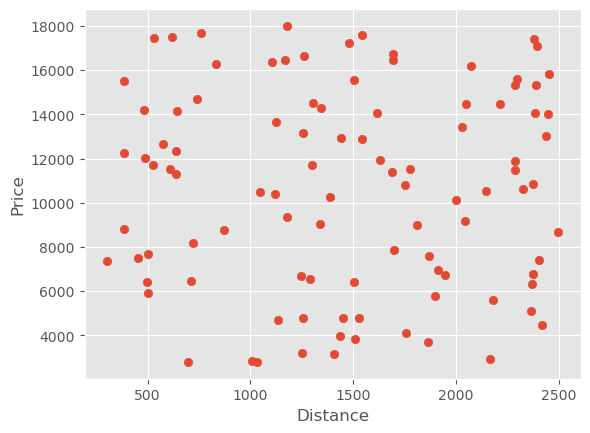

In [26]:
plt.scatter(df['Flight_Distance'],df['Ticket_Price'])
plt.xlabel('Distance')
plt.ylabel('Price')
plt.show()

# Business Insights
### -Identify top airlines.
### -Identify peak booking months.
### -Compare travel class popularity.
### -Recomended marketing strategies.
